In [35]:
# Get Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy import stats
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
import matplotlib.pyplot as plt
from scipy.stats import levene, ttest_ind, wilcoxon, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import shapiro
import xgboost as xgb
from shiny import App, render, ui
from tableone import TableOne

In [3]:
print(os.getcwd()) 

/Users/angela/DSprojects/Causal_Inference


In [7]:
data = pd.read_csv('./DataExtract.csv', header=2)

In [7]:
data.head()

,pdc,num_ip_post,total_los_post,num_op_post,num_er_post,num_ndc_post,num_gpi6_post,adjust_total_30d_post,generic_rate_post,post_ip_flag,...,brand_cost,ratio_G_total_cost,numofgen_post,numofbrand_post,generic_cost_post,brand_cost_post,ratio_G_total_cost_post,pdc_80_flag,drug_class,patient_key
0,0.894444,0,0,8,0,17,3,6.966667,1.000000,0,...,239.699550,0.710850,17,0,4332.043215,0.000000,1.000000,1,*ANTICOAGULANTS*,121
1,0.333333,0,0,4,0,15,5,14.466667,0.101382,0,...,2984.927229,0.010155,2,13,196.359216,3001.501507,0.061403,0,*ANTIDIABETICS*,168
2,0.077778,0,0,32,0,11,7,3.833333,0.739130,0,...,0.000000,1.000000,10,1,203.603270,1154.818505,0.149882,0,*ANTICOAGULANTS*,267
3,0.333333,0,0,57,0,16,6,24.000000,0.958333,0,...,160.804799,0.291008,15,1,140.952640,265.057382,0.347165,0,*ANTICOAGULANTS*,468
4,0.866667,0,0,5,0,16,4,18.000000,0.888889,0,...,0.000000,1.000000,14,2,671.755173,735.661568,0.477297,1,*ANTIDIABETICS*,499


In [9]:
data.patient_key.nunique()

3550

In [11]:
data.shape #no duplicate records

(3550, 95)

In [13]:
data_pdc_pop = data.groupby(['drug_class', 'pdc_80_flag']).patient_key.nunique()

In [15]:
data_pdc_pop

drug_class        pdc_80_flag
*ANTICOAGULANTS*  0              1437
                  1               391
*ANTIDIABETICS*   0              1051
                  1               671
Name: patient_key, dtype: int64

In [17]:
data_pdc_region = data.groupby(['drug_class', 'pdc_80_flag', 'regionN']).patient_key.nunique().reset_index()

In [19]:
data.groupby(['drug_class', 'pdc_80_flag', 'sexN']).patient_key.nunique()

drug_class        pdc_80_flag  sexN
*ANTICOAGULANTS*  0            1       661
                               2       776
                  1            1       228
                               2       163
*ANTIDIABETICS*   0            1       486
                               2       565
                  1            1       376
                               2       295
Name: patient_key, dtype: int64

In [9]:
from scipy.stats import chi2_contingency

# Filter data for ANTIDIABETICS drug class
AD = data[data['drug_class'].str.contains('ANTIDIABETICS')]


In [23]:

AD_df = AD.groupby(['pdc_80_flag'])['patient_key'].nunique().reset_index()

AD_df_encoded = pd.get_dummies(AD_df, columns = ['pdc_80_flag'])


chi2, p, _, _ = chi2_contingency(AD_df_encoded)

print(f'P-Value for Chi-Square Test: {p:.4f}')


P-Value for Chi-Square Test: 0.3321


In [31]:
# Filter data for ANTICOAGULANTS drug class
AC = data[data['drug_class'].str.contains('ANTICOAGULANTS')]

## Matched Cohort Analysis - AC

In [13]:
AC.columns

Index(['pdc', 'num_ip_post', 'total_los_post', 'num_op_post', 'num_er_post',
       'num_ndc_post', 'num_gpi6_post', 'adjust_total_30d_post',
       'generic_rate_post', 'post_ip_flag', 'post_er_flag', 'pdc_cat',
       'post_ip_cost', 'post_er_cost', 'post_rx_cost', 'post_op_cost',
       'post_total_cost', 'post_medical_cost', 'idx_copay', 'age_grpN', 'sexN',
       'regionN', 'idx_prodtypeN', 'idx_paytypN', 'age_cat', 'log_idx_copay',
       'ALCOHOL_DRUG', 'ASTHMA', 'CARDIAC_ARRYTHMIA', 'CARDIAC_VALVULAR',
       'CEREBROVASCULAR', 'CHRONIC_KIDNEY', 'CHRONIC_PAIN_FIBRO', 'CHF',
       'COPD', 'DEMENTIA', 'DEPRESSION', 'DIABETES', 'DYSLIPIDEMIA',
       'EPILEPSY_SEIZURE', 'HEPATITIS', 'HIV_AIDS', 'HYPERTENSION',
       'LIVER_GALLBLADDER_PANCREAS', 'MI_CAD', 'OSTEOARTHRITIS', 'PARALYSIS',
       'PEPTIC_ULCER', 'PERIPHERAL_VASCULAR', 'RENAL_FAILURE', 'RHEUMATOLOGIC',
       'SCHIZOPHRENIA', 'SLEEP_DISORDERS', 'SMOKING', 'THYROID', 'Solid_Tumor',
       'Metastatic', 'Leukemia_Lymph

In [313]:
# Ensure P_Value is numeric, forcing errors to NaN
AC_comorbidity['P_Value'] = pd.to_numeric(AC_comorbidity['P_Value'], errors='coerce')

# Set the significance level ( 0.05)
significance_level = 0.05

# Select features with p-values less than the threshold
significant_features = AC_comorbidity[AC_comorbidity['P_Value'] < significance_level]['category']

print("Significant Features:", significant_features.tolist())

Significant Features: ['age_19-44', 'age_45 - 64', 'age_65+', 'Northest', 'Midwest', 'South', 'West', 'ASTHMA', 'CARDIAC_VALVULAR', 'CHRONIC_PAIN_FIBRO', 'DEPRESSION', 'HYPERTENSION', 'OSTEOARTHRITIS', 'PARALYSIS', 'RHEUMATOLOGIC', 'SMOKING', 'THYROID', 'num_op_post', 'pre_total_cost', 'post_total_cost']


Data Transformation for AC

In [108]:
# --- Define columns ---
cat_cols = ["age_grpN", "regionN"]          # treat as categorical codes
num_cols = ["pre_er_cost", "pre_medical_cost", "pre_total_cost"]

# binary comorbidities (already 0/1) -> pass through without scaling
bin_cols = ["ASTHMA", "CARDIAC_VALVULAR", "CHRONIC_PAIN_FIBRO",
            "DEPRESSION", "HYPERTENSION", "OSTEOARTHRITIS", "PARALYSIS",
            "RHEUMATOLOGIC", "SMOKING", "THYROID"]

X = AC[cat_cols + num_cols + bin_cols].copy()
y = AC["pdc_80_flag"].copy()

# --- Preprocess: one-hot for categorical, scale numeric, passthrough binaries ---
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
        ("bin", "passthrough", bin_cols),
    ],
    remainder="drop"
)

ps_model = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=2000))
])

ps_model.fit(X, y)
AC = AC.copy()
AC["propensity_score"] = ps_model.predict_proba(X)[:, 1]

In [110]:
def calculate_smd(df, group_col, covariates):
    """
    Compute SMD for each covariate in a matched cohort dataset.

    Parameters:
    df (pd.DataFrame): The dataset containing the covariates and group label.
    group_col (str): The column name indicating treatment group (0 = control, 1 = treated).
    covariates (list): List of covariate column names.

    Returns:
    pd.DataFrame: SMD values for each covariate.
    """
    smd_results = {}

    # Split dataset into treated and control groups
    treated = df[df[group_col] == 1]
    control = df[df[group_col] == 0]

    for covariate in covariates:
        mean_treated = treated[covariate].mean()
        mean_control = control[covariate].mean()
        std_treated = treated[covariate].std()
        std_control = control[covariate].std()

        # Compute pooled standard deviation
        pooled_std = ((std_treated**2 + std_control**2) / 2)** 0.5

        # Compute SMD
        smd = abs(mean_treated - mean_control) / pooled_std
        smd_results[covariate] = smd

    return pd.DataFrame.from_dict(smd_results, orient='index', columns=['SMD']).sort_values(by='SMD', ascending=False)

# Example usage:
# Assuming `AC` is your dataset and `group` is the column indicating treatment/control (1/0)
# covariates_list = ['age', 'hypertension', 'smoking', 'dyslipidemia']
# smd_df = calculate_smd(AC, 'group', covariates_list)
# print(smd_df)


In [52]:
smd_pre = calculate_smd(AC, 'pdc_80_flag', X)
print("PRE-MATCH SMD")
print(smd_pre)

PRE-MATCH SMD
                         SMD
OSTEOARTHRITIS      0.582906
pre_medical_cost    0.323495
pre_total_cost      0.286092
CARDIAC_VALVULAR    0.246054
PARALYSIS           0.213689
SMOKING             0.172654
RHEUMATOLOGIC       0.164335
ASTHMA              0.135056
age_grpN            0.126861
CHRONIC_PAIN_FIBRO  0.126518
DEPRESSION          0.106036
pre_er_cost         0.090095
THYROID             0.066850
HYPERTENSION        0.042362
regionN             0.039201


While most covariates achieved acceptable balance (SMD < 0.2), OSTEOARTHRITIS  remained highly imbalanced (SMD > 0.58) 

In [112]:
from statsmodels.genmod.families.links import Log

# --- 1) Propensity score ---
prop_model = LogisticRegression(max_iter=1000)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
prop_model.fit(X_scaled, y)

AC = AC.copy()
AC["propensity_score"] = prop_model.predict_proba(X_scaled)[:, 1]

# --- 2) Split groups ---
treated = AC.loc[AC["pdc_80_flag"] == 1].copy().reset_index(drop=True)
control = AC.loc[AC["pdc_80_flag"] == 0].copy().reset_index(drop=True)

# --- 3) NN match: each control gets nearest treated ---
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(treated[["propensity_score"]])

dist, idx = nn.kneighbors(control[["propensity_score"]])

matched_control = control.copy()
matched_treated = treated.iloc[idx.flatten()].copy()

# Pair id for clustering later (optional but recommended)
matched_control["pair_id"] = np.arange(len(matched_control))
matched_treated["pair_id"] = np.arange(len(matched_treated))
matched_control["match_dist"] = dist.flatten()
matched_treated["match_dist"] = dist.flatten()

matched_data = pd.concat([matched_control, matched_treated], axis=0, ignore_index=True)

In [56]:
smd_post = calculate_smd(matched_data, 'pdc_80_flag', X)
print("POST-MATCH SMD")
print(smd_post)

POST-MATCH SMD
                         SMD
pre_er_cost         0.189017
age_grpN            0.150668
HYPERTENSION        0.121528
CARDIAC_VALVULAR    0.075461
ASTHMA              0.071126
DEPRESSION          0.066579
THYROID             0.043072
SMOKING             0.040245
RHEUMATOLOGIC       0.034458
OSTEOARTHRITIS      0.029356
PARALYSIS           0.020878
pre_medical_cost    0.019783
CHRONIC_PAIN_FIBRO  0.018709
regionN             0.015014
pre_total_cost      0.001561


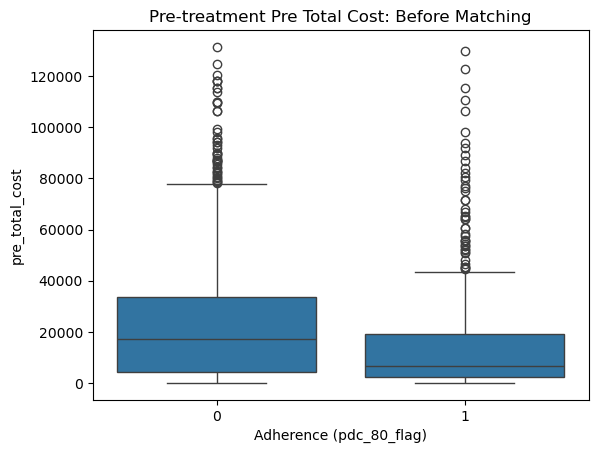

In [58]:
sns.boxplot(x=AC["pdc_80_flag"], y=AC["pre_total_cost"])
plt.title("Pre-treatment Pre Total Cost: Before Matching")
plt.xlabel("Adherence (pdc_80_flag)")
plt.ylabel("pre_total_cost")
plt.show()

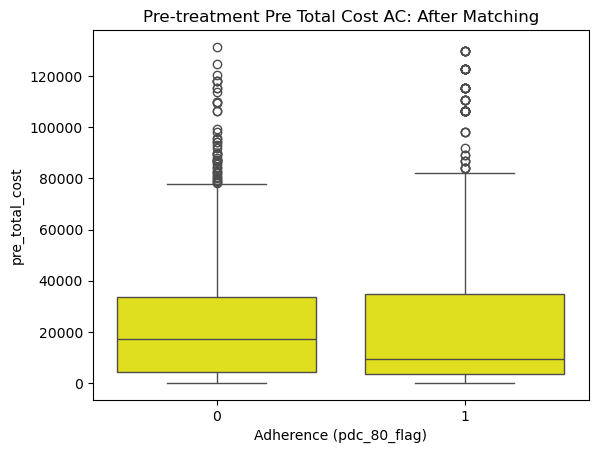

In [114]:
sns.boxplot(x=matched_data["pdc_80_flag"], y=matched_data["pre_total_cost"], color = "Yellow")
plt.title("Pre-treatment Pre Total Cost AC: After Matching")
plt.xlabel("Adherence (pdc_80_flag)")
plt.ylabel("pre_total_cost")
plt.show()

In [68]:
# 1) Define outcome + covariates
outcome = "post_total_cost"
covariates = [
    "pdc_80_flag", "age_grpN", "regionN",
    "ASTHMA", "CARDIAC_VALVULAR", "CHRONIC_PAIN_FIBRO",
    "DEPRESSION", "HYPERTENSION", "OSTEOARTHRITIS",
    "PARALYSIS", "RHEUMATOLOGIC", "SMOKING", "THYROID",
    "pre_er_cost", "pre_medical_cost", "pre_total_cost"
]

# 2) Build X and y from matched_data (drop rows with missing)
df = matched_data[[outcome] + covariates].dropna().copy()

y_matched = df[outcome]
X_matched = add_constant(df[covariates], has_constant="add")

# 3) Fit Gamma GLM (log link)
model = sm.GLM(y_matched, X_matched, family=sm.families.Gamma(link=Log()))
res = model.fit()

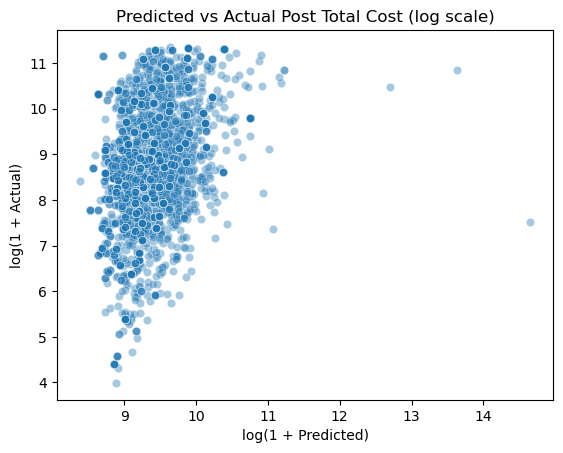

                 Generalized Linear Model Regression Results                  
Dep. Variable:        post_total_cost   No. Observations:                 2874
Model:                            GLM   Df Residuals:                     2857
Model Family:                   Gamma   Df Model:                           16
Link Function:                    Log   Scale:                          1.5544
Method:                          IRLS   Log-Likelihood:                -29944.
Date:                Wed, 17 Dec 2025   Deviance:                       3632.8
Time:                        20:40:42   Pearson chi2:                 4.44e+03
No. Iterations:                    34   Pseudo R-squ. (CS):             0.1113
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.5839      0

In [70]:
# 4) Predict + plot
df["predicted_cost"] = res.predict(X_matched)

sns.scatterplot(x=np.log1p(df["predicted_cost"]),
                y=np.log1p(df[outcome]),
                alpha=0.4)
plt.xlabel("log(1 + Predicted)")
plt.ylabel("log(1 + Actual)")
plt.title("Predicted vs Actual Post Total Cost (log scale)")
plt.show()

print(res.summary())

We used a Gamma GLM with a log link to estimate the effect of adherence (pdc_80_flag) on post-total medical cost in a matched cohort of anticoagulant users. pdc_80_flag = -0.2564 (p < 0.001)

Interpretation:

exp(-0.2564) − 1 ≈ -0.226

So adherent patients (pdc_80_flag=1) have about 22.6% lower expected post_total_cost than non-adherent, holding the listed baseline covariates constant.

The 95% CI in log units is [-0.349, -0.164]. Convert that too:

exp(-0.349) − 1 ≈ -29.4%

exp(-0.164) − 1 ≈ -15.1%

### AC Matched Cohort Analysis Interpretation
We used a Gamma GLM with a log link to estimate the effect of adherence (pdc_80_flag) on post-total medical cost in a matched cohort of anticoagulant users. Most pre-treatment covariates were well-balanced after matching (SMD < 0.2), In Summary:

“In the matched cohort, adherence is associated with ~23% lower expected post total cost (95% CI ~15% to 29% lower), using a Gamma log-link GLM.”

### Matched Cohort Analysis for Antidiabetic Drugs

In [339]:
AD.columns

Index(['pdc', 'num_ip_post', 'total_los_post', 'num_op_post', 'num_er_post',
       'num_ndc_post', 'num_gpi6_post', 'adjust_total_30d_post',
       'generic_rate_post', 'post_ip_flag', 'post_er_flag', 'pdc_cat',
       'post_ip_cost', 'post_er_cost', 'post_rx_cost', 'post_op_cost',
       'post_total_cost', 'post_medical_cost', 'idx_copay', 'age_grpN', 'sexN',
       'regionN', 'idx_prodtypeN', 'idx_paytypN', 'age_cat', 'log_idx_copay',
       'ALCOHOL_DRUG', 'ASTHMA', 'CARDIAC_ARRYTHMIA', 'CARDIAC_VALVULAR',
       'CEREBROVASCULAR', 'CHRONIC_KIDNEY', 'CHRONIC_PAIN_FIBRO', 'CHF',
       'COPD', 'DEMENTIA', 'DEPRESSION', 'DIABETES', 'DYSLIPIDEMIA',
       'EPILEPSY_SEIZURE', 'HEPATITIS', 'HIV_AIDS', 'HYPERTENSION',
       'LIVER_GALLBLADDER_PANCREAS', 'MI_CAD', 'OSTEOARTHRITIS', 'PARALYSIS',
       'PEPTIC_ULCER', 'PERIPHERAL_VASCULAR', 'RENAL_FAILURE', 'RHEUMATOLOGIC',
       'SCHIZOPHRENIA', 'SLEEP_DISORDERS', 'SMOKING', 'THYROID', 'Solid_Tumor',
       'Metastatic', 'Leukemia_Lymph

** Data Transformation **

In [116]:
# --- Define columns ---
cat_cols = ["age_grpN", "regionN"]          # treat as categorical codes
num_cols = ["pre_er_cost", "pre_medical_cost", "pre_total_cost", "ratio_G_total_cost", "brand_cost", "pre_rx_cost"
           ,"numofbrand", "num_ndc"]

X = AD[cat_cols + num_cols].copy()
y = AD["pdc_80_flag"].copy()

mask = X.notna().all(axis=1)
X2 = X.loc[mask].copy()
y2 = y.loc[mask].copy()

# --- Preprocess: one-hot for categorical, scale numeric, passthrough binaries ---
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    
    ],
    remainder="drop"
)

ps_model = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=2000))
])

ps_model.fit(X2, y2)

AD2 = AD.loc[mask].copy()
AD2["propensity_score"] = ps_model.predict_proba(X2)[:, 1]

In [341]:
X_reduced = AD[['pre_rx_cost', 'numofbrand', 'regionN','age_cat', 'num_ndc',
               'ratio_G_total_cost' , 'brand_cost', 'pre_medical_cost', 'pre_er_cost']]
y = AD['pdc_80_flag']

In [118]:
smd_pre = calculate_smd(AD2, 'pdc_80_flag', X2)
print("PRE-MATCH SMD for AD")
print(smd_pre)

PRE-MATCH SMD for AD
                         SMD
age_grpN            0.432524
num_ndc             0.247795
numofbrand          0.164062
regionN             0.144593
pre_rx_cost         0.128928
ratio_G_total_cost  0.121038
brand_cost          0.106367
pre_medical_cost    0.086150
pre_er_cost         0.056907
pre_total_cost      0.041213


In [120]:
from statsmodels.genmod.families.links import Log

# --- 2) Split groups ---
treated = AD2.loc[AD2["pdc_80_flag"] == 1].copy().reset_index(drop=True)
control = AD2.loc[AD2["pdc_80_flag"] == 0].copy().reset_index(drop=True)

# --- 3) NN match: each control gets nearest treated ---
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(treated[["propensity_score"]])

dist, idx = nn.kneighbors(control[["propensity_score"]])

matched_control = control.copy()
matched_treated = treated.iloc[idx.flatten()].copy()

# Pair id for clustering later (optional but recommended)
matched_control["pair_id"] = np.arange(len(matched_control))
matched_treated["pair_id"] = np.arange(len(matched_treated))
matched_control["match_dist"] = dist.flatten()
matched_treated["match_dist"] = dist.flatten()

matched_data = pd.concat([matched_control, matched_treated], axis=0, ignore_index=True)

In [122]:
smd_post = calculate_smd(matched_data, 'pdc_80_flag', X2)
print("POST-MATCH SMD for AD")
print(smd_post)

POST-MATCH SMD for AD
                         SMD
pre_medical_cost    0.126038
pre_total_cost      0.118486
pre_er_cost         0.075681
age_grpN            0.058046
numofbrand          0.043065
num_ndc             0.037334
brand_cost          0.035015
pre_rx_cost         0.025506
ratio_G_total_cost  0.004897
regionN             0.004393


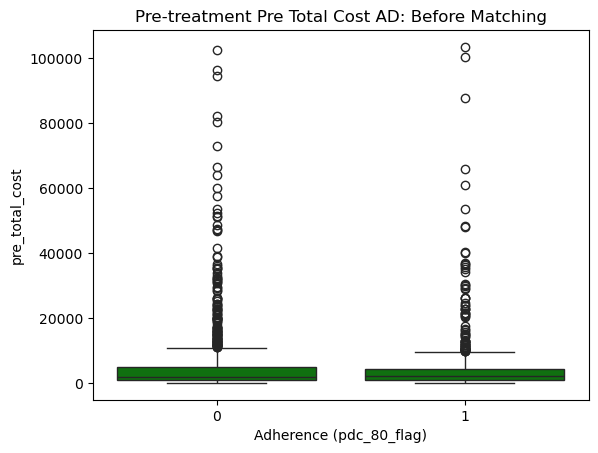

In [96]:
sns.boxplot(x="pdc_80_flag", y="pre_total_cost", data=AD2, color="Green")
plt.title("Pre-treatment Pre Total Cost AD: Before Matching")
plt.xlabel("Adherence (pdc_80_flag)")
plt.ylabel("pre_total_cost")
plt.show()

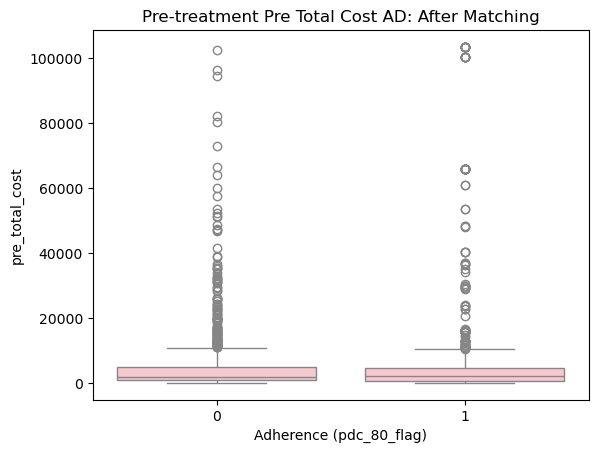

In [98]:
sns.boxplot(x=matched_data["pdc_80_flag"], y=matched_data["pre_total_cost"], color = "Pink")
plt.title("Pre-treatment Pre Total Cost AD: After Matching")
plt.xlabel("Adherence (pdc_80_flag)")
plt.ylabel("pre_total_cost")
plt.show()

In [126]:
# 1) Define outcome + covariates
outcome = "post_total_cost"
covariates = [
    "pdc_80_flag", "age_grpN", "regionN",
     "pre_rx_cost", "numofbrand", "num_ndc",
               "ratio_G_total_cost", "brand_cost", "pre_medical_cost", "pre_er_cost"
]

# 2) Build X and y from matched_data (drop rows with missing)
df = matched_data[[outcome] + covariates].dropna().copy()

y_matched = df[outcome]
X_matched = add_constant(df[covariates], has_constant="add")

# 3) Fit Gamma GLM (log link)
model = sm.GLM(y_matched, X_matched, family=sm.families.Gamma(link=Log()))
res = model.fit()

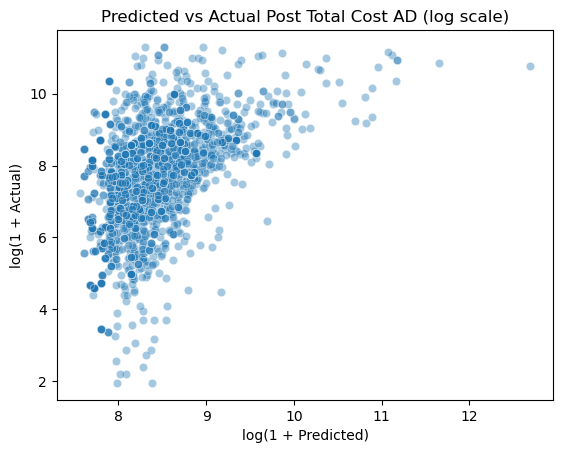

                 Generalized Linear Model Regression Results                  
Dep. Variable:        post_total_cost   No. Observations:                 1992
Model:                            GLM   Df Residuals:                     1981
Model Family:                   Gamma   Df Model:                           10
Link Function:                    Log   Scale:                          2.7215
Method:                          IRLS   Log-Likelihood:                -19083.
Date:                Wed, 17 Dec 2025   Deviance:                       2866.1
Time:                        21:16:04   Pearson chi2:                 5.39e+03
No. Iterations:                    22   Pseudo R-squ. (CS):             0.1105
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.1935      0

In [128]:
# 4) Predict + plot
df["predicted_cost"] = res.predict(X_matched)

sns.scatterplot(x=np.log1p(df["predicted_cost"]),
                y=np.log1p(df[outcome]),
                alpha=0.4)
plt.xlabel("log(1 + Predicted)")
plt.ylabel("log(1 + Actual)")
plt.title("Predicted vs Actual Post Total Cost AD (log scale)")
plt.show()

print(res.summary())

### Matched Cohort Analysis for Anti-diabetic Drugs - Interpretation
Because this is a Gamma GLM with log link, interpret pdc_80_flag multiplicatively:

pdc_80_flag coef = -0.2776, p < 0.001

Percent change in expected cost = exp(-0.2776) − 1

Let’s approximate:

exp(-0.2776) ≈ 0.758

0.758 − 1 ≈ −0.242

✅ Adherent patients have ~24% lower expected post_total_cost than non-adherent patients, in your matched cohort.

95% CI for the % change

CI in log units: [-0.423, -0.132]

exp(-0.423) − 1 ≈ −34%

exp(-0.132) − 1 ≈ −12%

In Summary:

“~24% lower (95% CI ~12% to 34% lower).”
2) Quick interpretation of a few other coefficients

age_grpN = 0.2051 (p=0.002): exp(0.205)−1 ≈ +23% per +1 unit of the coded age group (if it’s a code, this “per step” interpretation is why categorical encoding is often better).

regionN = -0.1017 (p=0.061): borderline; not quite significant at 0.05.

ratio_G_total_cost = -0.318 (p=0.011): higher generic share ratio associated with lower cost (direction makes sense).

pre_rx_cost and pre_medical_cost are positive and significant: higher baseline costs → higher post costs (expected).Using a Gamma GLM with log link on the matched cohort, adherence is associated with roughly a 24% reduction in expected post-total cost (exp(−0.278)−1), statistically significant.

In [131]:
matched_data["pdc_80_flag"].value_counts()

pdc_80_flag
0    996
1    996
Name: count, dtype: int64